# Debug Greedy Context Search

In [1]:
from matcha_dl import init_jvm
init_jvm('32G')

# Load source ontology

from mowl.datasets import PathDataset as OWLDataset
from pathlib import Path
DATA_DIR = Path.cwd() / "data"
NCIT_DIR = DATA_DIR / "ncit-doid"
source_ontology_file = str(NCIT_DIR / "ncit.owl")

source_onto = OWLDataset(source_ontology_file).ontology

In [2]:
# Load candidates file

test_cands_complete = Path.cwd() / "exp" / "generate_prompts" / "test_cands.tsv"
from matcha_dl.utils.data import read_table
df = read_table(test_cands_complete) 

In [3]:
# Load OntologyGraph for source ontology

from matcha_dl.core.entities.ontology import Entity
from org.semanticweb.HermiT import Reasoner
from org.semanticweb.owlapi.reasoner import InferenceType
reasoner = Reasoner.ReasonerFactory().createReasoner(source_onto)
reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)
from matcha_dl.core.entities.ontology import OntologyGraph
graph = OntologyGraph(source_onto, reasoner)

OWL2VecStar projection done!
	SubclassOf triples: 13437
	Equivalence triples: 28362
	Class assertion triples: 0
	Object property assertion triples: 0
	Domain and range triples: 92
	Annotation triples: 0


In [4]:
graph.cost_fn = lambda x: 10

In [5]:
graph.avg_edge_ic

7.115656929326835

In [6]:
# Load source entities from the candidates file

source_entities = Entity.load_from_list(df["SrcEntity"], 
                                        ontology=source_onto, 
                                        reasoner=reasoner, 
                                        ontology_graph=graph)

In [13]:
from matcha_dl.core.entities.configs.dataset import ContextMethod, BestPathMethod

source_entities[0].get_context_subgraph(n=3, human_readable=True, method=ContextMethod("greedy"), best_path_method=BestPathMethod("dp"), budget=254, hop_penalty=0.1)

[('Esophageal Verrucous Carcinoma', 'Disease_May_Have_Finding', 'Weight Loss'),
 ('Symptom', 'subclassof', 'Sign or Symptom'),
 ('Pushing Tumor Margin', 'subclassof', 'Tumor Margin Configuration'),
 ('Esophageal Squamous Cell', 'subclassof', 'Squamous Cell'),
 ('Pain', 'subclassof', 'Symptom'),
 ('Esophageal Squamous Cell Carcinoma',
  'Disease_Has_Normal_Cell_Origin',
  'Esophageal Squamous Cell'),
 ('Esophageal Verrucous Carcinoma', 'Disease_May_Have_Finding', 'Dysphagia'),
 ('Esophageal Verrucous Carcinoma', 'subclassof', 'Verrucous Carcinoma'),
 ('Regurgitation', 'subclassof', 'Sign'),
 ('Esophageal Verrucous Carcinoma', 'Disease_May_Have_Finding', 'Pain'),
 ('Esophageal Verrucous Carcinoma',
  'subclassof',
  'Esophageal Squamous Cell Carcinoma'),
 ('Mild Cytologic Atypia', 'subclassof', 'Cytologic Atypia'),
 ('Esophageal Verrucous Carcinoma',
  'Disease_May_Have_Finding',
  'Regurgitation'),
 ('Weight Change', 'subclassof', 'Sign'),
 ('Verrucous Carcinoma', 'Disease_Has_Finding',

# Random Tests

In [2]:
ds = TabularDataset()
ds.default_kind = "validation"
print(ds.default_kind) # DatasetMask.validation


DatasetMask.validation


In [ ]:
from abc import ABC, abstractmethod

class BaseClass(ABC):
    @abstractmethod
    def do_something(self, value):
        
        value = 1

class SubClass(BaseClass):
    def do_something(self):
        # Call the super method
        super().do_something()
        # Add subclass-specific implementation
        print("SubClass implementation")

# Usage
obj = SubClass()
obj.do_something()

In [2]:
# Tensor Logits
import torch
import torch.nn as nn

logits = torch.tensor([[1.0, 2.0, 3.0], [1.0, 2.0, 3.0], [1.0, 2.0, 3.0]])

logits.to("cuda")
print(logits.device)
logits.round().cpu().int().numpy()


cpu


array([[1, 2, 3],
       [1, 2, 3],
       [1, 2, 3]], dtype=int32)

In [4]:
from enum import Enum

class AggregationStrategy(str, Enum):
    max = "max"
    min = "min"
    mean = "mean"

AggregationStrategy(AggregationStrategy.max)

<AggregationStrategy.max: 'max'>

In [1]:
from matcha_dl import init_jvm
init_jvm('32G')

from mowl.datasets import PathDataset as OWLDataset
from pathlib import Path
DATA_DIR = Path.cwd() / "data"
NCIT_DIR = DATA_DIR / "ncit-doid"
source_ontology_file = str(NCIT_DIR / "ncit.owl")
target_ontology_file = str(NCIT_DIR / "doid.owl")


source_onto = OWLDataset(source_ontology_file).ontology
target_onto = OWLDataset(target_ontology_file).ontology

In [21]:
from mowl.projection import OWL2VecStarProjector
projector = OWL2VecStarProjector()
edges = projector.project(source_onto)

OWL2VecStar projection done!
	SubclassOf triples: 13437
	Equivalence triples: 28362
	Class assertion triples: 0
	Object property assertion triples: 0
	Domain and range triples: 92
	Annotation triples: 0


In [33]:
relation_types = {edge.rel for edge in edges}
print(relation_types)

{'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R172', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R175', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R31', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R106', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R103', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R39', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R145', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R53', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R32', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R24', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R168', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R81', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R34', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R141', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R51', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R37', 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R27', 'http:

In [45]:
from matcha_dl.core.entities.ontology import Entity

test = [ent.labels for ent in Entity.load_from_list(list(relation_types), source_onto)]

In [38]:
no_label_ents = [ent.name for ent in test if not ent.labels]
print(no_label_ents)

['subclassof']


In [3]:
test_cands_complete = Path.cwd() / "exp" / "generate_prompts" / "test_cands.tsv"
from matcha_dl.utils.data import read_table
df = read_table(test_cands_complete)  # Check if the file exists

from ast import literal_eval
flattened_data = []
for _, row in df.iterrows():
    src_entity = row['SrcEntity']
    tgt_entity = row['TgtEntity']
    candidates = row['TgtCandidates']
    for candidate in literal_eval(candidates):
        flattened_data.append({
            'SrcEntity': src_entity,
            'TgtEntity': tgt_entity,
            'Candidate': candidate,
            'Label': 1 if candidate == tgt_entity else 0
        })

In [4]:
import pandas as pd
df = pd.DataFrame(flattened_data)
df

,SrcEntity,TgtEntity,Candidate,Label
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3747,http://purl.obolibrary.org/obo/DOID_0080171,0
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3747,http://purl.obolibrary.org/obo/DOID_9261,0
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3747,http://purl.obolibrary.org/obo/DOID_8649,0
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3747,http://purl.obolibrary.org/obo/DOID_0060464,0
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3747,http://purl.obolibrary.org/obo/DOID_10927,0
...,...,...,...,...
4995,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5612,http://purl.obolibrary.org/obo/DOID_5877,0
4996,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5612,http://purl.obolibrary.org/obo/DOID_3637,0
4997,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5612,http://purl.obolibrary.org/obo/DOID_13742,0
4998,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5612,http://purl.obolibrary.org/obo/DOID_0110633,0


In [2]:
from matcha_dl.core.entities.ontology import Entity
from org.semanticweb.HermiT import Reasoner
from org.semanticweb.owlapi.reasoner import InferenceType
reasoner = Reasoner.ReasonerFactory().createReasoner(source_onto)
reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)
from matcha_dl.core.entities.ontology import OntologyGraph
graph = OntologyGraph(source_onto, reasoner)

OWL2VecStar projection done!
	SubclassOf triples: 13437
	Equivalence triples: 28362
	Class assertion triples: 0
	Object property assertion triples: 0
	Domain and range triples: 92
	Annotation triples: 0


In [ ]:
import numpy as np
df['features'] = list(np.array(ordered_entities).T)

In [47]:
np.array(df['features'].values.tolist()).T[0]

array([Entity(name=C27420, labels=['Esophageal Verrucous Carcinoma'], subclasses=[], top_superclass=['Disease, Disorder or Finding'], superclasses=['Esophageal Squamous Cell Carcinoma', 'Verrucous Carcinoma']),
       Entity(name=C27420, labels=['Esophageal Verrucous Carcinoma'], subclasses=[], top_superclass=['Disease, Disorder or Finding'], superclasses=['Esophageal Squamous Cell Carcinoma', 'Verrucous Carcinoma']),
       Entity(name=C27420, labels=['Esophageal Verrucous Carcinoma'], subclasses=[], top_superclass=['Disease, Disorder or Finding'], superclasses=['Esophageal Squamous Cell Carcinoma', 'Verrucous Carcinoma']),
       ...,
       Entity(name=C3572, labels=['Malignant Spinal Cord Neoplasm'], subclasses=['Spinal Cord Embryonal Tumor, Not Otherwise Specified', 'Metastatic Malignant Neoplasm in the Spinal Cord', 'Spinal Cord Lymphoma', 'Spinal Cord Melanoma', 'Spinal Cord Neuroblastoma', 'Spinal Cord Sarcoma'], top_superclass=['Disease, Disorder or Finding'], superclasses=['S

In [5]:
source_entities = Entity.load_from_list(df["SrcEntity"], 
                                        ontology=source_onto, 
                                        reasoner=reasoner, 
                                        ontology_graph=graph)
target_entities = Entity.load_from_list(df["SrcEntity"], 
                                        ontology=source_onto, 
                                        reasoner=reasoner, 
                                        ontology_graph=graph)

In [6]:
ordered_entities = [source_entities, target_entities]

In [7]:
graph.cost_fn = lambda x : 30

In [8]:
graph._edge_cost_cache

{('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38632',
  'http://subclassof',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C13033'): 30,
 ('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C34749',
  'http://subclassof',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C26808'): 30,
 ('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C36765',
  'http://subclassof',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C36763'): 30,
 ('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C99361',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R132',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C27711'): 30,
 ('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C99361',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#R153',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C27711'): 30,
 ('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C79740',
  'http://subclassof',
  'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C14262'): 30,


In [10]:
from matcha_dl.core.entities.ontology import ContextMethod, BestPathMethod

ordered_entities[0][0].get_context_subgraph(n=1, human_readable=True, method=ContextMethod("greedy"), best_path_method=BestPathMethod("greedy"), budget=60, hop_penalty=0.1)

KeyboardInterrupt: 

In [10]:
source_context = [source.get_context_subgraph(2) for source in ordered_entities[0]]
target_context = [target.get_context_subgraph(2) for target in ordered_entities[1]]

In [11]:
context_graph_list = [source_context, target_context]

In [14]:
source_context[0]

[('Musculoskeletal Pain', 'subclassof', 'Pain'),
 ('Flank Pain', 'subclassof', 'Pain'),
 ('Weight Change', 'subclassof', 'Sign'),
 ('TP53 Gene', 'Gene_Associated_With_Disease', 'Nasopharyngeal Carcinoma'),
 ('Dysphagia', 'subclassof', 'Digestive System Signs and Symptoms'),
 ('TP53 Gene Inactivation',
  'Molecular_Abnormality_Involves_Gene',
  'TP53 Gene'),
 ('Abdominal Pain', 'subclassof', 'Pain'),
 ('TP53 Gene', 'Gene_Has_Abnormality', 'TP53 Gene Inactivation'),
 ('TP53 Gene', 'Allele_Has_Abnormality', 'TP53 Gene Inactivation'),
 ('Back Pain', 'subclassof', 'Pain'),
 ('Pain', 'subclassof', 'Symptom'),
 ('Bone Pain', 'subclassof', 'Pain'),
 ('TP53 Gene',
  'Gene_Involved_In_Pathogenesis_Of_Disease',
  'Gastroesophageal Junction Adenocarcinoma'),
 ('TP53 Gene',
  'Gene_Involved_In_Pathogenesis_Of_Disease',
  'Ampulla of Vater Adenocarcinoma'),
 ('Regurgitation', 'subclassof', 'Sign'),
 ('TP53 Gene', 'Gene_Associated_With_Disease', 'Hepatocellular Carcinoma'),
 ('TP53 Gene',
  'Gene_Inv

In [3]:
from org.semanticweb.HermiT import Reasoner
from org.semanticweb.owlapi.reasoner import InferenceType
reasoner = Reasoner.ReasonerFactory().createReasoner(source_onto)
reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)

In [12]:
from matcha_dl.core.entities.ontology import Entity
test1 = [ent.labels for ent in Entity.load_from_list(df['SrcEntity'].tolist(), source_onto, reasoner=reasoner)]

In [4]:
from matcha_dl.core.entities.ontology import OntologyGraph
graph = OntologyGraph(source_onto, reasoner)

OWL2VecStar projection done!
	SubclassOf triples: 13437
	Equivalence triples: 28362
	Class assertion triples: 0
	Object property assertion triples: 0
	Domain and range triples: 92
	Annotation triples: 0


In [5]:
examples = graph.get_example_triples(2, exclude_missing_dr=False, human_readable=True)

In [6]:
examples

{'Disease_Excludes_Cytogenetic_Abnormality': [('Uterine Corpus Low Grade Endometrial Stromal Sarcoma',
   'Disease_Excludes_Cytogenetic_Abnormality',
   't(10;17)(q22;p13)'),
  ('Thymic Undifferentiated Carcinoma',
   'Disease_Excludes_Cytogenetic_Abnormality',
   't(15;19)(q13;p13.1)')],
 'Allele_Plays_Altered_Role_In_Process': [('ATM Gene',
   'Allele_Plays_Altered_Role_In_Process',
   'DNA Repair'),
  ('Cytochrome P450 Family Gene',
   'Allele_Plays_Altered_Role_In_Process',
   'Oxidation/Reduction')],
 'EO_Disease_Maps_To_Human_Disease': [('Experimental Organism Diagnosis',
   'EO_Disease_Maps_To_Human_Disease',
   'Disease, Disorder or Finding')],
 'Gene_Mutant_Encodes_Gene_Product_Sequence_Variation': [('TP53 Gene Mutation',
   'Gene_Mutant_Encodes_Gene_Product_Sequence_Variation',
   'TP53 Protein Variant'),
  ('PDGFRA Gene Mutation',
   'Gene_Mutant_Encodes_Gene_Product_Sequence_Variation',
   'PDGFRA Protein Variant')],
 'Disease_Has_Primary_Anatomic_Site': [('Head and Neck Pr

In [11]:
examples['Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'][0][1]

'Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'

In [15]:
from matcha_dl.core.entities.ontology import Entity
test1 = [ent.get_context_subgraph(2) for ent in Entity.load_from_list(df['SrcEntity'].tolist(), source_onto, ontology_graph=graph)]

In [ ]:
from matcha_dl.core.entities.ontology import Entity

df['SrcEntityLabel'] = [ent.get_context_subgraph(3) for ent in Entity.load_from_list(df['SrcEntity'].tolist(), source_onto)]
df['TgtEntityLabel'] = [ent.get_context_subgraph(3) for ent in Entity.load_from_list(df['TgtEntity'].tolist(), target_onto)]
df['TgtCandLabel'] = [ent.get_context_subgraph(3) for ent in Entity.load_from_list(df['Candidate'].tolist(), target_onto)]




In [2]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B")
# model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B")

# model = model.to("cuda")

In [3]:
tokenizer.model_max_length

16384

In [24]:
test_verb_string = "You are a natural language generator that converts structured data into a coherent sentence. Given the triple below, generate one complete, grammatically correct sentence that clearly expresses the relationship between the source and the target as indicated by the relation. Make sure the sentence uses the source and target. Do not include any additional commentary or information. The triple is: source: $SRC, relation: $REL, target: $TGT. The sentence should be: <think>"
test_verb_string = test_verb_string.replace("$SRC", examples['Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'][1][0])
test_verb_string = test_verb_string.replace("$REL", examples['Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'][1][1])
test_verb_string = test_verb_string.replace("$TGT", examples['Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'][1][2])

import re

def extract_answer(response):
    """
    Extracts all content after the </think> tag, removing any line breaks that directly follow this tag.

    Parameters:
    response (str): The complete response string.

    Returns:
    str: The extracted content after </think> with leading line breaks removed.
    """
    # Split the response at the </think> tag
    parts = response.split('</think>', 1)
    if len(parts) > 1:
        # Remove any leading whitespace or line breaks after </think>
        return parts[1].lstrip()
    return ''

import torch

inputs = tokenizer(test_verb_string, return_tensors="pt").to("cuda")
with torch.no_grad():
    model.eval()
    outputs = model.generate(**inputs, max_length=5000)
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
answer = extract_answer(generated_text)
print(answer)
answer = answer.replace(examples['Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'][1][0], "$SRC")
answer = answer.replace(examples['Gene_Mutant_Encodes_Gene_Product_Sequence_Variation'][1][2], "$TGT")
print(answer)




Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


The PDGFRA Gene Mutation encodes a Gene_Mutant that is the PDGFRA Protein Variant.
The $SRC encodes a Gene_Mutant that is the $TGT.


In [23]:
test_verb_string

'You are a natural language generator that converts structured data into a coherent sentence. Given the triple below, generate one complete, grammatically correct sentence that clearly expresses the relationship between the source and the target as indicated by the relation. Make sure the sentence uses the source and target. Do not include any additional commentary or information. The triple is: source: PDGFRA Gene Mutation, relation: Gene_Mutant_Encodes_Gene_Product_Sequence_Variation, target: PDGFRA Protein Variant. The sentence should be: <think>'

In [24]:
generated_text

'You are a natural language generator that converts structured data into a coherent sentence. Given the triple below, generate one complete, grammatically correct sentence that clearly expresses the relationship between the source and the target as indicated by the relation. Do not include any additional commentary or information. The triple is: source: Esophageal Verrucous Carcinoma, relation: subclassof, target: Verrucous Carcinoma. The sentence should be: <think><think>\nOkay, so I\'ve got this query where the user wants me to act as a natural language generator. They provided a triple with source, relation, and target. The source is Esophageal Verrucous Carcinoma, the relation is subclassof, and the target is Verrucous Carcinoma. They want a coherent sentence that clearly shows the subclass relationship.\n\nHmm, I need to make sure the sentence is grammatically correct and flows naturally. The example response they gave was "Esophageal Verrucous Carcinoma is a subclass of Verrucous

In [56]:
df.to_csv(Path.cwd() / "exp" / "generate_prompts" / "test_cands_flattened_with_labels.tsv", sep="\t", index=False)

In [66]:
# filter label == 0 and SrcEntity == http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C34880

df_filtered = df[(df['Label'] == 0) & (df['SrcEntity'] == "http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C7581")]
df_filtered


,SrcEntity,TgtEntity,Candidate,Label,SrcEntityLabel,TgtEntityLabel,TgtCandLabel
4301,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_0050570,0,Microcystic Adnexal Carcinoma,malignant syringoma,congenital disorder of glycosylation type I
4302,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_0090129,0,Microcystic Adnexal Carcinoma,malignant syringoma,carnitine palmitoyltransferase I deficiency
4303,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_0110764,0,Microcystic Adnexal Carcinoma,malignant syringoma,hereditary spastic paraplegia 11
4304,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_14749,0,Microcystic Adnexal Carcinoma,malignant syringoma,methylmalonic acidemia
4305,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_8543,0,Microcystic Adnexal Carcinoma,malignant syringoma,"Hodgkin's lymphoma, lymphocytic-histiocytic pr..."
...,...,...,...,...,...,...,...
4395,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_0110671,0,Microcystic Adnexal Carcinoma,malignant syringoma,congenital myasthenic syndrome 6
4396,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_0110156,0,Microcystic Adnexal Carcinoma,malignant syringoma,Charcot-Marie-Tooth disease type 2B1
4397,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_0060642,0,Microcystic Adnexal Carcinoma,malignant syringoma,recessive dystrophic epidermolysis bullosa
4398,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_5569,http://purl.obolibrary.org/obo/DOID_898,0,Microcystic Adnexal Carcinoma,malignant syringoma,autosomal dominant polycystic kidney disease


In [1]:
from matcha_dl.core.contracts.model import IModel

class MyModel(IModel):

    def forward(self, x):
        return x

In [5]:
import torch

a = MyModel()
print(a(torch.tensor([1, 2, 3])))

tensor([1, 2, 3])


In [ ]:
from matcha_dl.core.entities.dataset import StaticPrompts
import pandas as pd
import torch
from typing import List, Tuple, Union

def vectorized_parse_critic_responses(critic_responses: List[str], fallback: torch.Tensor) -> torch.Tensor:
        """
        Given a list of critic responses and a fallback tensor (the original model confidences),
        return a tensor of critic labels (1.0 for positive, -1.0 for negative, 0.0 for uncertain).
        
        Any response that does not match any condition falls back to the corresponding fallback value.
        """
        _unexpected_response_count = 0
        # Convert responses to a Pandas Series and clean them
        s = pd.Series(critic_responses).str.lower().str.strip()
        
        # Create boolean masks for each condition
        pos_mask = s.str.contains(StaticPrompts.POSITIVE_SOLUTION.lower(), na=False)
        neg_mask = s.str.contains(StaticPrompts.NEGATIVE_SOLUTION.lower(), na=False)
        uncertain_mask = s.str.contains(StaticPrompts.UNCERTAIN_SOLUTION.lower(), na=False)

        print(f"Positive mask: {pos_mask}")
        print(f"Negative mask: {neg_mask}")
        print(f"Uncertain mask: {uncertain_mask}")

        # Count unexpected responses (those that do not match any condition)
        recognized_mask = pos_mask | neg_mask | uncertain_mask
        _unexpected_response_count += int((~recognized_mask).sum())

        # count how many have more then one mask
        multiple_mask = pos_mask & neg_mask | pos_mask & uncertain_mask | neg_mask & uncertain_mask
        _unexpected_response_count += int(multiple_mask.sum())
        
        # Initialize critic labels with zeros
        critic_labels = pd.Series(0.0, index=s.index)
        # Set labels based on the masks
        critic_labels[pos_mask] = 1.0
        critic_labels[neg_mask] = -1.0
        critic_labels[uncertain_mask] = 0.0
        
        # For entries that did not match any condition, fallback to the corresponding predicted confidence
        fallback_np = fallback.cpu().numpy() 
        critic_labels[~recognized_mask] = fallback_np[~recognized_mask]
        
        # Return as a torch tensor
        return torch.tensor(critic_labels.values, dtype=torch.float32, device="cpu"), _unexpected_response_count

In [ ]:
critic_responses = ["yes", "no", "uncertain", "other"]
fallback = torch.tensor([0.85, 0.85, 0.85, 0.85], dtype=torch.float32)

tensor, error = vectorized_parse_critic_responses(critic_responses, fallback)

print(tensor)  # Output: tensor([ 1.0000, -1.0000,  0.0000,  0.8500])
print(error)  # Output: 1 (for the "unknown" response)

Positive mask: 0     True
1    False
2    False
3    False
dtype: bool
Negative mask: 0    False
1     True
2    False
3     True
dtype: bool
Uncertain mask: 0    False
1    False
2     True
3    False
dtype: bool
tensor([ 1., -1.,  0., -1.])
0


In [ ]:
_unexpected_response_count = {'multiple_responses': 0, 'no_conf': 0, 'no_signal': 0}

In [8]:
class UnexpectedResponseCount:
    def __init__(self):
        self.multiple_responses = 0
        self.no_conf = 0
        self.no_signal = 0


In [9]:
unexpected = UnexpectedResponseCount()

In [12]:
unexpected.multiple_responses

1

In [7]:
from typing import Any, get_type_hints
from pydantic import BaseModel, field_validator

class MyModel(BaseModel):
    my_field: int
    my_field_2: int

    @field_validator('my_field', 'my_field_2', mode='before')
    def validate_my_field(cls, value, info) -> Any:
        # Retrieve the type hints for the model
        print(value)
        return value
    


In [9]:
MyModel(my_field=10, my_field_2=20)

10
20


MyModel(my_field=10, my_field_2=20)

In [10]:
from pydantic import BaseModel, model_validator, ValidationError
from typing import Optional

class DatasetParams(BaseModel):
    validation_set: Optional[float]
    label_cardinality: Optional[int]

    @model_validator(mode="after")
    def check_consistency(self) -> "DatasetParams":
        if self.validation_set is not None:
            if not (0.0 <= self.validation_set <= 1.0):
                raise ValueError("validation_set must be between 0.0 and 1.0")

        if self.label_cardinality is not None:
            if self.label_cardinality < 1:
                raise ValueError("label_cardinality must be at least 1")

        # Example comparison:
        if self.validation_set is not None and self.label_cardinality is not None:
            if self.validation_set > (1 / self.label_cardinality):
                raise ValueError(
                    "validation_set is too large given the label_cardinality"
                )
        return self

In [11]:
DatasetParams(validation_set=0.2, label_cardinality=5)

DatasetParams(validation_set=0.2, label_cardinality=5)

In [9]:
example = [True, False, True]

example is None or not any(example)

False

In [9]:
import re
def remove_if_followed(sentence: str, target: str, follow: str) -> str:
    """
    Remove the target phrase if it is immediately followed by the follow word.
    """
    # Build a regex pattern:
    # - \b ensures we match the target at a word boundary.
    # - re.escape(target) escapes any regex-special characters in target.
    # - \s+ matches one or more whitespace characters after the target.
    # - (?=...) is a positive lookahead ensuring that the following word is 'follow'.
    # - \b after follow to ensure a whole-word match.
    pattern = rf'\b{re.escape(target)}\s+(?={re.escape(follow)}\b)'
    
    # Replace the matching target (and following whitespace) with an empty string.
    return re.sub(pattern, '', sentence)

In [11]:
remove_if_followed("This is a test target follow", "target", "follow")

'This is a test follow'

In [3]:

import enum
from pydantic import BaseModel
from typing import List, Optional

class Fruit(enum.Enum):
    apple = "apple"
    banana = "banana"

class MyModel(BaseModel):
    fruit: Optional[List[Optional[Fruit]]]

m = MyModel(fruit=["apple", "banana", None])
print(m.fruit) 

[<Fruit.apple: 'apple'>, <Fruit.banana: 'banana'>, None]


In [6]:
import torch

target = torch.tensor([[0.0]])
logits = torch.tensor([0.5])

In [8]:
target.squeeze(1)

tensor([0.])

In [6]:
from pathlib import Path
EXP_DIR = Path.cwd() / "tests" / "test_data"
candidates_file = EXP_DIR /  "full.tsv"

In [7]:
from matcha_dl.utils.data import read_table
df = read_table(candidates_file)

In [8]:
df

,SrcEntity,TgtEntity,Score
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_13593,1.0
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_1357,1.0
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_7664,1.0
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_4927,1.0
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_9537,1.0
5,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_2621,1.0
6,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_9279,1.0
7,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3829,1.0
8,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_6612,1.0
9,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_3747 1.0,NaN


Debug get context subgraph

In [1]:
from matcha_dl import init_jvm
init_jvm('32G')

from mowl.datasets import PathDataset as OWLDataset
from pathlib import Path
DATA_DIR = Path.cwd() / "data"
NCIT_DIR = DATA_DIR / "ncit-doid"
source_ontology_file = str(NCIT_DIR / "ncit.owl")
target_ontology_file = str(NCIT_DIR / "doid.owl")


source_onto = OWLDataset(source_ontology_file).ontology
target_onto = OWLDataset(target_ontology_file).ontology


from org.semanticweb.HermiT import Reasoner
from org.semanticweb.owlapi.reasoner import InferenceType
reasoner = Reasoner.ReasonerFactory().createReasoner(source_onto)
reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)

from matcha_dl.core.entities.ontology import OntologyGraph
graph = OntologyGraph(source_onto, reasoner)

OWL2VecStar projection done!
	SubclassOf triples: 13437
	Equivalence triples: 28362
	Class assertion triples: 0
	Object property assertion triples: 0
	Domain and range triples: 92
	Annotation triples: 0


In [5]:
graph.graph.get("http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38632")

{'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C13033',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38516'}

In [14]:
graph.graph.get("http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38516")

{'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C12801',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C12802',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38632',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C4825'}

In [6]:
graph.get_labels('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38632')

['Tonsil Part']

In [7]:
graph.get_labels('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C13033')

['Immune System Part']

In [8]:
graph.get_labels('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38516')

['Tonsillar Tissue']

In [42]:
n = 1
from collections import deque

start = "http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C27420"

visited = {start: 0}
queue = deque([start])
while queue:
    node = queue.popleft()
    dist = visited[node]
    if dist < n:
        for nbr in graph.graph.get(node, []):
            if nbr not in visited:
                visited[nbr] = dist + 1
                queue.append(nbr)
reachable = set(visited.keys())


In [43]:
len(reachable)

7

In [18]:
graph.graph.get("http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C13033").union(graph.graph.get("http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38516")).union(graph.graph.get("http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C38632")) == reachable

True

In [38]:
graph.get_labels("http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C3303")

['Pain']

In [29]:
graph.graph.get('http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C27420')

{'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C2980',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C3303',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C3445',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C3781',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C4024',
 'http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C50726'}

In [44]:
for i in reachable:
    print(graph.get_labels(i))

['Weight Loss']
['Esophageal Verrucous Carcinoma']
['Pain']
['Verrucous Carcinoma']
['Regurgitation']
['Esophageal Squamous Cell Carcinoma']
['Dysphagia']


In [46]:
subgraph_edges= []
for edge in graph.edges:
            if edge.src in reachable and edge.dst in reachable:

                src = graph.get_labels(edge.src)[0]
                dst = graph.get_labels(edge.dst)[0]
                rel = graph.get_labels(edge.rel)[0]

                # original (outgoing) triple
                subgraph_edges.append((src, rel, dst))


In [47]:
subgraph_edges

[('Esophageal Verrucous Carcinoma', 'subclassof', 'Verrucous Carcinoma'),
 ('Esophageal Verrucous Carcinoma',
  'subclassof',
  'Esophageal Squamous Cell Carcinoma'),
 ('Esophageal Verrucous Carcinoma', 'Disease_May_Have_Finding', 'Dysphagia'),
 ('Esophageal Verrucous Carcinoma', 'Disease_May_Have_Finding', 'Pain'),
 ('Esophageal Verrucous Carcinoma', 'Disease_May_Have_Finding', 'Weight Loss'),
 ('Esophageal Verrucous Carcinoma',
  'Disease_May_Have_Finding',
  'Regurgitation')]

# Alignment Analysis

## Omim-Ordo

In [10]:
from matcha_dl import init_jvm
init_jvm('32G')

from matcha_dl.utils.data import read_table
from pathlib import Path

df = read_table(Path('/home/pgcotovio/Matcha-DL/exp/unsup_local_all_datasets/omim-ordo/dataset/dataset.csv'))
alignment = read_table(Path('/home/pgcotovio/Matcha-DL/exp/unsup_local_all_datasets/omim-ordo/model/alignment/src2tgt.maps_local.tsv'))
alignment.columns = ['Src', 'Tgt', 'TgtCandidates']



In [15]:
import pandas as pd
from ast import literal_eval

# Initialize empty list to store flattened data
flattened_data = []

# Create a features dictionary from the original dataframe
features_dict = {}
if 'inference' in df.columns and 'prefiltered' in df.columns:
    filtered_df = df[(df['inference'] == True) & (df['prefiltered'] == False)]
    
    if 'Features' in filtered_df.columns and len(filtered_df) > 0:
        # Create a mapping of Src -> features
        for _, row in filtered_df.iterrows():
            if 'Src' in row or 'SrcEntity' in row:
                src_key = row.get('Src', row.get('SrcEntity'))
                features_dict[src_key] = row['Features']

# Process each row in the alignment dataframe
for idx, row in alignment.iterrows():
    src_entity = row['Src']
    tgt_entity = row['Tgt']
    candidates_str = row['TgtCandidates']
    
    # Parse the candidates string into a list of tuples (entity, score)
    candidates = literal_eval(candidates_str)
    
    # Sort candidates by score (assuming higher score is better)
    sorted_candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    
    # Create a row for each candidate
    for rank, (candidate, score) in enumerate(sorted_candidates, 1):
        row_data = {
            'Src': src_entity,
            'Tgt': tgt_entity,
            'Candidate': candidate,
            'Score': score,
            'match_id': idx,
            'ranking': rank,
            'is_correct': candidate == tgt_entity
        }
        
        # Add features if available for this source entity
        if src_entity in features_dict:
            row_data['features'] = features_dict[src_entity]
        
        flattened_data.append(row_data)

# Create the flattened DataFrame
flattened_df = pd.DataFrame(flattened_data)

# Display the first few rows
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,features
0,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_163971,0.584531,0,1,False,"['', 'Rare developmental defect during embryog..."
1,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_85279,0.572849,0,2,False,"['', 'Rare developmental defect during embryog..."
2,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_98791,0.565855,0,3,False,"['', 'Rare developmental defect during embryog..."
3,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_457223,0.562222,0,4,False,"['', 'Rare developmental defect during embryog..."
4,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_243,0.558602,0,5,False,"['', 'Rare developmental defect during embryog..."


In [17]:
# remove all rows with empty features

flattened_df = flattened_df[flattened_df['features'].notna()]
flattened_df = flattened_df[flattened_df['features'].notnull()]
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,features
0,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_163971,0.584531,0,1,False,"['', 'Rare developmental defect during embryog..."
1,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_85279,0.572849,0,2,False,"['', 'Rare developmental defect during embryog..."
2,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_98791,0.565855,0,3,False,"['', 'Rare developmental defect during embryog..."
3,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_457223,0.562222,0,4,False,"['', 'Rare developmental defect during embryog..."
4,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_243,0.558602,0,5,False,"['', 'Rare developmental defect during embryog..."


In [23]:
flattened_df['features'][0]

"['', 'Rare developmental defect during embryogenesis is a subclass of group of disorders.']"

In [24]:
# Separate features list of size 2 into two columns source context and target context (run eval on features saved has string)
import ast
import pandas as pd
import numpy as np

def split_features_column(df, column_name):
    """
    Splits a column containing lists into two separate columns.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the column to split.
        column_name (str): The name of the column to split.
        
    Returns:
        pd.DataFrame: A new DataFrame with the split columns.
    """
    # Convert the string representation of lists back to actual lists
    df[column_name] = df[column_name].apply(ast.literal_eval)
    
    # Create two new columns from the list
    df[['source_context', 'target_context']] = pd.DataFrame(df[column_name].tolist(), index=df.index)
    
    # Drop the original column
    df = df.drop(columns=[column_name])
    
    return df

flattened_df = split_features_column(flattened_df, 'features')
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,source_context,target_context
0,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_163971,0.584531,0,1,False,,Rare developmental defect during embryogenesis...
1,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_85279,0.572849,0,2,False,,Rare developmental defect during embryogenesis...
2,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_98791,0.565855,0,3,False,,Rare developmental defect during embryogenesis...
3,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_457223,0.562222,0,4,False,,Rare developmental defect during embryogenesis...
4,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_243,0.558602,0,5,False,,Rare developmental defect during embryogenesis...


In [25]:
flattened_df.source_context.value_counts()

source_context
                                                                                                                                    72922
bleeding disorder, platelet-type, 8 is a subclass of Bleeding disorder, platelet-type.                                                101
meckel syndrome 12 is a subclass of Meckel syndrome.                                                                                  101
ficolin 3 deficiency is a subclass of Lectin complement activation pathway defects.                                                   101
arthrogryposis, distal,  iia 2a is a subclass of Arthrogryposis, distal.                                                              101
                                                                                                                                    ...  
mitochondrial complex 4 deficiency, nuclear  iia 1 is a subclass of Mitochondrial complex IV deficiency, nuclear-type.                101
van esch-o'driscoll

In [26]:
# Load source ontology

from mowl.datasets import PathDataset as OWLDataset
DATA_DIR = Path.cwd() / "data"
NCIT_DIR = DATA_DIR / "omim-ordo"
source_ontology_file = str(NCIT_DIR / "omim.owl")
target_ontology_file = str(NCIT_DIR / "ordo.owl")

source_onto = OWLDataset(source_ontology_file).ontology
target_onto = OWLDataset(target_ontology_file).ontology


In [29]:
# Load OntologyGraph for source ontology

from matcha_dl.core.entities.ontology import Entity
from org.semanticweb.HermiT import Reasoner
from org.semanticweb.owlapi.reasoner import InferenceType
source_reasoner = Reasoner.ReasonerFactory().createReasoner(source_onto)
source_reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)

target_reasoner = Reasoner.ReasonerFactory().createReasoner(target_onto)
target_reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)

source_ents_labels = [ent.labels[0] for ent in Entity.load_from_list(flattened_df['Src'].tolist(), source_onto, reasoner=source_reasoner)]
target_ents_labels = [ent.labels[0] for ent in Entity.load_from_list(flattened_df['Tgt'].tolist(), target_onto, reasoner=target_reasoner)]

flattened_df['SrcEntityLabel'] = source_ents_labels
flattened_df['TgtEntityLabel'] = target_ents_labels
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,source_context,target_context,SrcEntityLabel,TgtEntityLabel
0,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_163971,0.584531,0,1,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability
1,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_85279,0.572849,0,2,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability
2,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_98791,0.565855,0,3,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability
3,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_457223,0.562222,0,4,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability
4,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_243,0.558602,0,5,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability


In [31]:
# use all-mini model to generate embeddings for the source and target context and had them two other columns

# Import the SentenceTransformer model
from sentence_transformers import SentenceTransformer
import torch

# Load the all-MiniLM model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Generate embeddings for source and target contexts
print("Generating source context embeddings...")
source_embeddings = model.encode(flattened_df['source_context'].tolist(), 
                                 batch_size=32, 
                                 show_progress_bar=True)

print("Generating target context embeddings...")
target_embeddings = model.encode(flattened_df['target_context'].tolist(), 
                                 batch_size=32, 
                                 show_progress_bar=True)

# Add embeddings as new columns to the DataFrame
flattened_df['source_embeddings'] = list(source_embeddings)
flattened_df['target_embeddings'] = list(target_embeddings)

# Display the first few rows to verify
print(f"DataFrame shape after adding embeddings: {flattened_df.shape}")
flattened_df.head()

Generating source context embeddings...


Batches:   0%|          | 0/3286 [00:00<?, ?it/s]

Generating target context embeddings...


Batches:   0%|          | 0/3286 [00:00<?, ?it/s]

DataFrame shape after adding embeddings: (105141, 13)


,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,source_context,target_context,SrcEntityLabel,TgtEntityLabel,source_embeddings,target_embeddings
0,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_163971,0.584531,0,1,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability,"[-0.118838385, 0.04829869, -0.0025481049, -0.0...","[-0.047265932, -0.048013687, -0.016687848, 0.0..."
1,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_85279,0.572849,0,2,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability,"[-0.11883838, 0.04829872, -0.0025480525, -0.01...","[-0.047265932, -0.048013687, -0.016687848, 0.0..."
2,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_98791,0.565855,0,3,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability,"[-0.11883838, 0.04829872, -0.0025480525, -0.01...","[-0.047265932, -0.048013687, -0.016687848, 0.0..."
3,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_457223,0.562222,0,4,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability,"[-0.11883838, 0.04829872, -0.0025480525, -0.01...","[-0.047265932, -0.048013687, -0.016687848, 0.0..."
4,http://www.omim.org/phenotypicSeries/PS309510,http://www.orpha.net/ORDO/Orphanet_98464,http://www.orpha.net/ORDO/Orphanet_243,0.558602,0,5,False,,Rare developmental defect during embryogenesis...,"Intellectual developmental disorder, X-linked ...",X-linked syndromic intellectual disability,"[-0.11883838, 0.04829872, -0.0025480525, -0.01...","[-0.047265932, -0.048013687, -0.016687848, 0.0..."


In [34]:
# Save dataframe without embeddings
flattened_df.drop(columns=['source_embeddings', 'target_embeddings'], inplace=True)
flattened_df.to_csv(Path.cwd() / "exp" / "unsup_local_all_datasets" / "omim-ordo" / "dataset" / "dataset_without_embeddings.csv", sep="\t", index=False)

## NCIT-DOID

In [35]:
from matcha_dl import init_jvm
init_jvm('32G')

from matcha_dl.utils.data import read_table
from pathlib import Path

df = read_table(Path('/home/pgcotovio/Matcha-DL/exp/unsup_local_all_datasets/ncit2doid/dataset/dataset.csv'))
alignment = read_table(Path('/home/pgcotovio/Matcha-DL/exp/unsup_local_all_datasets/ncit2doid/model/alignment/src2tgt.maps_local.tsv'))
alignment.columns = ['Src', 'Tgt', 'TgtCandidates']



In [36]:
import pandas as pd
from ast import literal_eval

# Initialize empty list to store flattened data
flattened_data = []

# Create a features dictionary from the original dataframe
features_dict = {}
if 'inference' in df.columns and 'prefiltered' in df.columns:
    filtered_df = df[(df['inference'] == True) & (df['prefiltered'] == False)]
    
    if 'Features' in filtered_df.columns and len(filtered_df) > 0:
        # Create a mapping of Src -> features
        for _, row in filtered_df.iterrows():
            if 'Src' in row or 'SrcEntity' in row:
                src_key = row.get('Src', row.get('SrcEntity'))
                features_dict[src_key] = row['Features']

# Process each row in the alignment dataframe
for idx, row in alignment.iterrows():
    src_entity = row['Src']
    tgt_entity = row['Tgt']
    candidates_str = row['TgtCandidates']
    
    # Parse the candidates string into a list of tuples (entity, score)
    candidates = literal_eval(candidates_str)
    
    # Sort candidates by score (assuming higher score is better)
    sorted_candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    
    # Create a row for each candidate
    for rank, (candidate, score) in enumerate(sorted_candidates, 1):
        row_data = {
            'Src': src_entity,
            'Tgt': tgt_entity,
            'Candidate': candidate,
            'Score': score,
            'match_id': idx,
            'ranking': rank,
            'is_correct': candidate == tgt_entity
        }
        
        # Add features if available for this source entity
        if src_entity in features_dict:
            row_data['features'] = features_dict[src_entity]
        
        flattened_data.append(row_data)

# Create the flattened DataFrame
flattened_df = pd.DataFrame(flattened_data)

# Display the first few rows
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,features
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050806,0.708204,0,1,True,"['""the disease causes the exclusion of the Nod..."
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0060108,0.659315,0,2,False,"['""the disease causes the exclusion of the Nod..."
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050804,0.659088,0,3,False,"['""the disease causes the exclusion of the Nod..."
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_3073,0.652271,0,4,False,"['""the disease causes the exclusion of the Nod..."
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_4202,0.644334,0,5,False,"['""the disease causes the exclusion of the Nod..."


In [37]:
# remove all rows with empty features

flattened_df = flattened_df[flattened_df['features'].notna()]
flattened_df = flattened_df[flattened_df['features'].notnull()]
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,features
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050806,0.708204,0,1,True,"['""the disease causes the exclusion of the Nod..."
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0060108,0.659315,0,2,False,"['""the disease causes the exclusion of the Nod..."
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050804,0.659088,0,3,False,"['""the disease causes the exclusion of the Nod..."
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_3073,0.652271,0,4,False,"['""the disease causes the exclusion of the Nod..."
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_4202,0.644334,0,5,False,"['""the disease causes the exclusion of the Nod..."


In [38]:
flattened_df['features'][0]

'[\'"the disease causes the exclusion of the Nodular Pattern from the Neural Glioblastoma." Neural Glioblastoma is a subclass of Glioblastoma by Gene Expression Profile. the head Neural Glioblastoma has a finding, which is Neuronal Differentiation.\', \'diencephalic neoplasm is a subclass of supratentorial cancer.\']'

In [39]:
# Separate features list of size 2 into two columns source context and target context (run eval on features saved has string)
import ast
import pandas as pd
import numpy as np

def split_features_column(df, column_name):
    """
    Splits a column containing lists into two separate columns.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the column to split.
        column_name (str): The name of the column to split.
        
    Returns:
        pd.DataFrame: A new DataFrame with the split columns.
    """
    # Convert the string representation of lists back to actual lists
    df[column_name] = df[column_name].apply(ast.literal_eval)
    
    # Create two new columns from the list
    df[['source_context', 'target_context']] = pd.DataFrame(df[column_name].tolist(), index=df.index)
    
    # Drop the original column
    df = df.drop(columns=[column_name])
    
    return df

flattened_df = split_features_column(flattened_df, 'features')
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,source_context,target_context
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050806,0.708204,0,1,True,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0060108,0.659315,0,2,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050804,0.659088,0,3,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_3073,0.652271,0,4,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_4202,0.644334,0,5,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...


In [40]:
flattened_df.source_context.value_counts()

source_context
Adrenal Cortex Carcinoma may have a finding related to Tumor Vascular Invasion. Adrenal Cortex Carcinoma is a subclass of Malignant Adrenal Cortex Neoplasm. Adrenal Cortex Carcinoma has normal tissue origin, which is Adrenal Cortex. "Adrenal Cortex Carcinoma has a normal cell origin, which is why it is associated with Glandular Cell." Adrenal Cortex Carcinoma has normal tissue origin, which is Glandular Epithelium. Adrenal Cortex Carcinoma may have a finding related to Fever. Adrenal Cortex Carcinoma is a subclass of Infrequent Neoplasm. Adrenal Cortex Carcinoma may have an associated disease, Cushing Syndrome. Adrenal Cortex Carcinoma is a subclass of Malignant Endocrine Neoplasm. Adrenal Cortex Carcinoma may have a finding related to Abnormal Virilization. Adrenal Cortex Carcinoma may have a finding related to Flank Pain. Adrenal Cortex Carcinoma may have a finding related to Capsular Invasion. Adrenal Cortex Carcinoma is a subclass of Adenocarcinoma. "the disease has 

In [41]:
# Load source ontology

from mowl.datasets import PathDataset as OWLDataset
DATA_DIR = Path.cwd() / "data"
NCIT_DIR = DATA_DIR / "ncit-doid"
source_ontology_file = str(NCIT_DIR / "ncit.owl")
target_ontology_file = str(NCIT_DIR / "doid.owl")

source_onto = OWLDataset(source_ontology_file).ontology
target_onto = OWLDataset(target_ontology_file).ontology


In [42]:
# Load OntologyGraph for source ontology

from matcha_dl.core.entities.ontology import Entity
from org.semanticweb.HermiT import Reasoner
from org.semanticweb.owlapi.reasoner import InferenceType
source_reasoner = Reasoner.ReasonerFactory().createReasoner(source_onto)
source_reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)

target_reasoner = Reasoner.ReasonerFactory().createReasoner(target_onto)
target_reasoner.precomputeInferences(InferenceType.CLASS_HIERARCHY, InferenceType.OBJECT_PROPERTY_HIERARCHY)

source_ents_labels = [ent.labels[0] for ent in Entity.load_from_list(flattened_df['Src'].tolist(), source_onto, reasoner=source_reasoner)]
target_ents_labels = [ent.labels[0] for ent in Entity.load_from_list(flattened_df['Tgt'].tolist(), target_onto, reasoner=target_reasoner)]

flattened_df['SrcEntityLabel'] = source_ents_labels
flattened_df['TgtEntityLabel'] = target_ents_labels
flattened_df.head()

,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,source_context,target_context,SrcEntityLabel,TgtEntityLabel
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050806,0.708204,0,1,True,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0060108,0.659315,0,2,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050804,0.659088,0,3,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_3073,0.652271,0,4,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_4202,0.644334,0,5,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype


In [43]:
# use all-mini model to generate embeddings for the source and target context and had them two other columns

# Import the SentenceTransformer model
from sentence_transformers import SentenceTransformer
import torch

# Load the all-MiniLM model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Generate embeddings for source and target contexts
print("Generating source context embeddings...")
source_embeddings = model.encode(flattened_df['source_context'].tolist(), 
                                 batch_size=32, 
                                 show_progress_bar=True)

print("Generating target context embeddings...")
target_embeddings = model.encode(flattened_df['target_context'].tolist(), 
                                 batch_size=32, 
                                 show_progress_bar=True)

# Add embeddings as new columns to the DataFrame
flattened_df['source_embeddings'] = list(source_embeddings)
flattened_df['target_embeddings'] = list(target_embeddings)

# Display the first few rows to verify
print(f"DataFrame shape after adding embeddings: {flattened_df.shape}")
flattened_df.head()

Generating source context embeddings...


Batches:   0%|          | 0/2033 [00:00<?, ?it/s]

Generating target context embeddings...


Batches:   0%|          | 0/2033 [00:00<?, ?it/s]

DataFrame shape after adding embeddings: (65044, 13)


,Src,Tgt,Candidate,Score,match_id,ranking,is_correct,source_context,target_context,SrcEntityLabel,TgtEntityLabel,source_embeddings,target_embeddings
0,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050806,0.708204,0,1,True,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype,"[-0.083477855, 0.062101096, -0.0086167725, -0....","[0.0013390498, -0.0076942584, -0.09538324, -0...."
1,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0060108,0.659315,0,2,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype,"[-0.083477855, 0.062101096, -0.0086167725, -0....","[0.0013390498, -0.0076942584, -0.09538324, -0...."
2,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_0050804,0.659088,0,3,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype,"[-0.083477855, 0.062101096, -0.0086167725, -0....","[0.0013390448, -0.007694259, -0.09538325, -0.0..."
3,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_3073,0.652271,0,4,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype,"[-0.083477855, 0.062101096, -0.0086167725, -0....","[0.0013390448, -0.007694259, -0.09538325, -0.0..."
4,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,http://purl.obolibrary.org/obo/DOID_0050806,http://purl.obolibrary.org/obo/DOID_4202,0.644334,0,5,False,"""the disease causes the exclusion of the Nodul...",diencephalic neoplasm is a subclass of suprate...,Neural Glioblastoma,glioblastoma neural subtype,"[-0.083477855, 0.062101096, -0.0086167725, -0....","[0.0013390448, -0.007694259, -0.09538325, -0.0..."


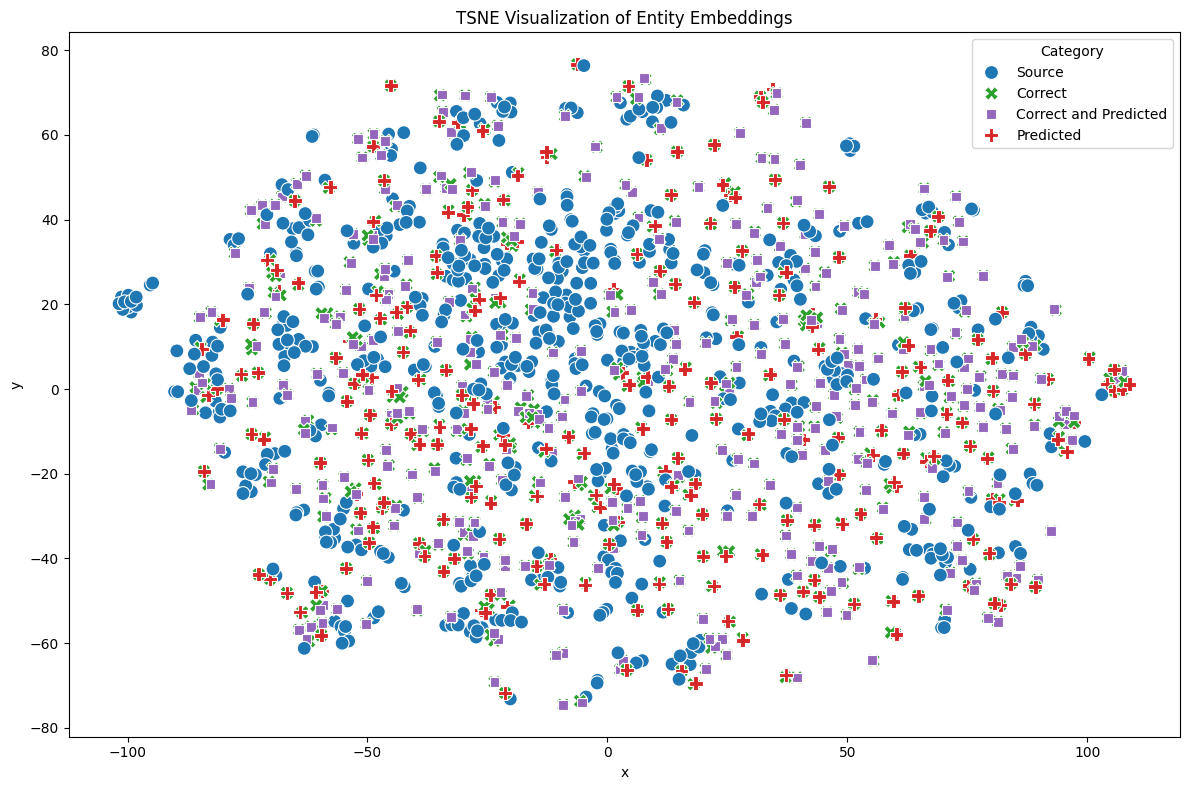

In [44]:
# Import necessary libraries
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a new DataFrame for plotting
plot_data = []

# Process each unique source entity
for src in flattened_df['Src'].unique():
    src_rows = flattened_df[flattened_df['Src'] == src]
    
    # Add source entity
    src_row = src_rows.iloc[0]  # Take the first row for this source
    plot_data.append({
        'embedding': src_row['source_embeddings'],
        'category': 'Source',
        'label': src_row.get('SrcEntityLabel', src)
    })
    
    # Add correct mapping
    correct_row = src_rows[src_rows['is_correct'] == True]
    if not correct_row.empty:
        plot_data.append({
            'embedding': correct_row.iloc[0]['target_embeddings'],
            'category': 'Correct',
            'label': correct_row.iloc[0].get('TgtEntityLabel', correct_row.iloc[0]['Candidate'])
        })
    
    # Add predicted mapping (rank 1)
    predicted_row = src_rows[src_rows['ranking'] == 1]
    if not predicted_row.empty:
        # Check if it's also the correct mapping
        if predicted_row.iloc[0]['is_correct'] == True:
            category = 'Correct and Predicted'
        else:
            category = 'Predicted'
        
        plot_data.append({
            'embedding': predicted_row.iloc[0]['target_embeddings'],
            'category': category,
            'label': predicted_row.iloc[0].get('TgtEntityLabel', predicted_row.iloc[0]['Candidate'])
        })

# Convert to DataFrame
plot_df = pd.DataFrame(plot_data)

# Extract embeddings for TSNE
embeddings = np.array(plot_df['embedding'].tolist())

# Determine appropriate perplexity value
perplexity = min(30, max(5, len(embeddings) // 5))

# Apply TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
embeddings_2d = tsne.fit_transform(embeddings)

# Add 2D coordinates to DataFrame
plot_df['x'] = embeddings_2d[:, 0]
plot_df['y'] = embeddings_2d[:, 1]

# Set a colorblind-friendly palette
color_map = {
    'Source': '#1f77b4',  # Blue
    'Correct': '#2ca02c',  # Green
    'Predicted': '#d62728',  # Red
    'Correct and Predicted': '#9467bd'  # Purple
}

# Create the plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df, 
    x='x', 
    y='y', 
    hue='category', 
    palette=color_map,
    style='category',  # Different markers for each category
    s=100  # Point size
)

plt.title('TSNE Visualization of Entity Embeddings')
plt.legend(title='Category')
plt.tight_layout()

# Save and display the plot
plt.savefig('entity_embeddings_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
# Save dataframe without embeddings
flattened_df.drop(columns=['source_embeddings', 'target_embeddings'], inplace=True)
flattened_df.to_csv(Path.cwd() / "exp" / "unsup_local_all_datasets" / "ncit2doid" / "dataset" / "dataset_without_embeddings.csv", sep="\t", index=False)